In [ ]:
!pip install g2p-en
!pip install textgrid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.7 MB/s eta 0:00:00
  Created wheel for distance: filename=Distance-0.1.3-py3-none-any.whl size=16256 sha256=e88a8877a7931aba72eb29ca71ea1ee18b8ba07dee0d5ac6524a170ffce4870b
  Stored in directory: /root/.cache/pip/wheels/24/a8/58/407063d8e5c1d4dd6594c99d12baa0108570b56a92325587dd
Successfully built distance
  Preparing metadata (setup.py) ... done
  Created wheel for textgrid: filename=TextGrid-1.6.1-py3-none-any.whl size=10146 sha256=4017a60a0ef164e066f4b9662b6f702a87dbe70593a43262dbbcca92bdadca1c
  Stored in directory: /root/.cache/pip/wheels/ce/86/7b/5766bd19fa4b4554667dd186e614b5a438ab14eec9c5a3642a
Successfully built textgrid


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
import librosa
from torch.nn.utils.rnn import pad_sequence
import kagglehub
import pandas as pd
import nltk
from g2p_en import G2p

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:

g2p = G2p()
nltk.download("averaged_perceptron_tagger_eng")
# Download latest version
path = kagglehub.dataset_download("mathurinache/the-lj-speech-dataset")
print("Path to dataset files:", path)
amount = 13000

df = pd.read_csv(path+'/LJSpeech-1.1/metadata.csv',sep='|',header=None)
df = df.iloc[:, 1].tolist()
df = df[:amount]
all_phonemes = []
for line in df:
    phonemes = g2p(line)
    all_phonemes.extend(phonemes)

chars = sorted(set(all_phonemes))
stoi = {s:i for i,s in enumerate(chars)}
vocab = len(stoi)

def encode(x):
  x = x.lower()
  x = g2p(x)
  return [stoi[s] for s in x]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Using Colab cache for faster access to the 'the-lj-speech-dataset' dataset.
Path to dataset files: /kaggle/input/the-lj-speech-dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import librosa
from textgrid import TextGrid


dur_path = "/content/drive/MyDrive/LJSpeech/"
wav_path = path + "/LJSpeech-1.1/wavs"

d = []
p = os.listdir(wav_path)[:amount]
for i in p:
  new = i.replace('.wav','.TextGrid')
  d.append(new)

phoneme_frames_list = []
spectrograms = []

for wav_file, tg_file in zip(p, d):
    # ---- Load audio ----
    x, sr = librosa.load(os.path.join(wav_path, wav_file), sr=22050)

    mel = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=80)
    mel = librosa.power_to_db(mel)
    spec = torch.tensor(mel, dtype=torch.float).transpose(0, 1)
    num_frames = spec.shape[0]

    # ---- Load TextGrid (NEW object each time) ----
    tg = TextGrid()
    tg.read(os.path.join(dur_path, tg_file))

    phones_tier = None
    for tier in tg.tiers:
        if tier.name == "phones":
            phones_tier = tier
            break

    if phones_tier is None:
        raise ValueError(f"No 'phones' tier in {tg_file}")

    # ---- Durations in seconds ----
    durations = [
        interval.maxTime - interval.minTime
        for interval in phones_tier.intervals
    ]

    total_time = sum(durations)
    if total_time == 0:
        raise ValueError(f"Total duration is zero in {tg_file}")

    # ---- Convert time → frames ----
    time_to_frame = num_frames / total_time
    phoneme_frames = [
        int(round(d * time_to_frame)) for d in durations
    ]

    # ---- Fix rounding mismatch ----
    diff = num_frames - sum(phoneme_frames)
    if diff != 0:
        longest_idx = np.argmax(phoneme_frames)
        phoneme_frames[longest_idx] += diff

    phoneme_frames = torch.tensor(phoneme_frames, dtype=torch.long)
    phoneme_frames_list.append(phoneme_frames)
    spectrograms.append(spec)

# ---- Padding ----
spectrograms = pad_sequence(
    spectrograms,
    batch_first=True,
    padding_value=0
)  # (B, T, 80)

spectrograms = spectrograms.transpose(1, 2).to(device)  # (B, 80, T)

# Text processing
inp = []
for i in df:
  inp.append(torch.tensor(encode(i),dtype=torch.long))
inp = pad_sequence(inp, batch_first=True, padding_value=vocab+1).to(device)

# Duration Processing
duration = []
for i in phoneme_frames_list:
  i = torch.log1p(i)
  pad_i = F.pad(i,(0,inp.shape[1]-len(i)))
  duration.append(pad_i)
duration = torch.stack(duration).to(device)



In [ ]:
torch.save(spectrograms, 'spectrograms.pth')
torch.save(inp, 'text.pth')
torch.save(duration,'duration.pth')

In [ ]:
spectrograms = torch.load("/content/drive/MyDrive/TTS train/spectrograms.pth").to(device)
duration = torch.load("/content/drive/MyDrive/TTS train/duration.pth").to(device)
inp = torch.load("/content/drive/MyDrive/TTS train/text.pth").to(device)
vocab=77

In [ ]:
#Mel processing
def make_sp_ma(x,pad_idx):
  return (x != pad_idx)
ma = make_sp_ma(spectrograms,0)

n = torch.sum(ma)
sp_mean = torch.sum(spectrograms) / n

sp_std = torch.sqrt(torch.sum((spectrograms - sp_mean) ** 2) / n)
spectrograms = (spectrograms - sp_mean) / sp_std
spectrograms = spectrograms * ma



# Data Split
spl = round(inp.shape[0]*0.9)
inp_train = inp[:spl]
duration_train = duration[:spl]
spectrograms_train = spectrograms[:spl]

inp_val = inp[spl:]
duration_val = duration[spl:]
spectrograms_val = spectrograms[spl:]
ma = ma[:spl]
ma_val = ma[spl:]

In [ ]:
from torch.utils.data import Dataset, DataLoader

class SpectrogramDataset(Dataset):
    def __init__(self, inp, spectrograms,dur,ma):
        self.inp = inp
        self.dur = dur
        self.spec = spectrograms
        self.masks = ma


    def __len__(self):
        return len(self.inp)

    def __getitem__(self, idx):
        return self.inp[idx], self.spec[idx],self.dur[idx],self.masks[idx]

batch_size = 32
dataset = SpectrogramDataset(inp_train, spectrograms_train,duration_train,ma)
loader = DataLoader(dataset, batch_size=batch_size)

dataset_Va = SpectrogramDataset(inp_val, spectrograms_val,duration_val,ma_val)
loader_va = DataLoader(dataset, batch_size=10)


In [ ]:
def length_regulator(x,dur):
    output = []
    masks = []
    for batch_idx in range(x.size(0)):
        te = dur[batch_idx]
        cleaned = te[te != 0]
        d_s = len(cleaned)
        repeated = torch.repeat_interleave(x[batch_idx][:d_s], cleaned, dim=0)
        m = torch.ones(sum(cleaned),dtype=torch.bool)
        m = F.pad(m, (0, mel_len - sum(cleaned)), value=False )
        masks.append(m)
        repeated = F.pad(repeated, (0, 0, 0, mel_len - repeated.size(0)), value=0)
        output.append(repeated)
    out = torch.stack(output).to(device)
    mask = torch.stack(masks).to(device)
    return out,mask

In [ ]:
import sys
def make_mask(x,pad_idx):
  return (x != pad_idx)

layers = 4
d_model = 568
heads = 4
dropout = 0.2
mel_len = spectrograms.shape[2]
seq_len = inp.shape[1]

class Duration_predictor(nn.Module):
  def __init__(self,d_model,dropout=0.1):
    super().__init__()
    self.conv1 = nn.Conv1d(d_model,d_model*4,kernel_size=3,padding=1,)
    self.conv2 = nn.Conv1d(d_model*4,d_model,kernel_size=3,padding=1)
    self.norm1 = nn.RMSNorm(d_model)
    self.norm2 = nn.RMSNorm(d_model)
    self.lin = nn.Linear(d_model,1)
    self.act = nn.ReLU()
    self.dropout = nn.Dropout(dropout)
  def forward(self,x):
    res = x
    x = self.norm1(x)
    x = x.transpose(1,2)
    x = self.act(self.conv1(x))
    x = self.dropout(x)


    x = self.act(self.conv2(x))
    x = self.dropout(x)
    x = x.transpose(1,2)
    x = self.norm2(x) + res
    x = self.lin(x)
    return x



class positional_encodings(nn.Module):
  def __init__(self):
    super().__init__()
    self.pos_emb = nn.Embedding(1000,d_model)
  def forward(self,x):
    pos = torch.arange(x.shape[1],device=device).unsqueeze(0)
    return self.pos_emb(pos)


class Attention(nn.Module):
  def __init__(self,d_model,heads,dropout=0.1):
    super().__init__()
    assert d_model % heads == 0, "d_model must be divisible by n_head"
    self.d_model = d_model
    self.heads = heads
    self.resid_dropout = nn.Dropout(dropout)
    self.head_dim = d_model // heads
    self.att_proj = nn.Linear(d_model,3*d_model,bias = False)
    self.c_proj = nn.Linear(d_model, d_model, bias = False)

  def forward(self,x,padding_mask):

    B,T,C = x.shape
    q,k,v  = self.att_proj(x).split(self.d_model,dim=2)
    q = q.view(B, T, self.heads,C // self.heads).transpose(1, 2)
    k = k.view(B, T, self.heads, C // self.heads).transpose(1, 2) # (B, nh, T, hs)
    v = v.view(B, T, self.heads, C // self.heads).transpose(1, 2) # (B, nh, T, hs)

    padding_mask = torch.where(padding_mask, torch.tensor(0., dtype=torch.float32), torch.tensor(float('-inf')))
    attn_mask = padding_mask.unsqueeze(1).unsqueeze(2)
    attn_mask = attn_mask.expand(B,1,T,T)

    y = F.scaled_dot_product_attention(q,k,v, attn_mask=attn_mask, enable_gqa=True,)
    y = y.transpose(1, 2).contiguous().view(B, T, C)
    y = self.resid_dropout(self.c_proj(y))
    return y




class FFT_layer(nn.Module):
    def __init__(self, d_model, heads, dropout=0.1):
        super().__init__()
        self.mha = Attention(d_model,heads,dropout)
        self.norm1 = nn.RMSNorm(d_model)
        self.norm2 = nn.RMSNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Conv1d(d_model, 4*d_model, kernel_size=1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(4*d_model, d_model, kernel_size=1),
            nn.Dropout(dropout)
        )

    def forward(self, x, key_padding_mask=None):
        h = self.norm1(x)
        attn_out = self.mha(h,key_padding_mask)
        x = x + attn_out
        h = self.norm2(x)
        h = h.transpose(1, 2)          # (B, C, T)
        h = self.ffn(h)
        h = h.transpose(1, 2)        # (B, T, C)

        x = x + h
        return x

class FFT_Block(nn.Module):
    def __init__(self, d_model, heads,layers, dropout=0.1):
        super().__init__()
        self.blocks = nn.ModuleList([FFT_layer(d_model, heads, dropout) for _ in range(layers)])
        self.norm = nn.RMSNorm(d_model)
    def forward(self,x,k_mask):
      for layer in self.blocks:
        x = layer(x,key_padding_mask=k_mask)
      return self.norm(x)

class TTS(nn.Module):
  def __init__(self,d_model,layers,heads,dropout):
    super().__init__()
    self.embedding = nn.Embedding(vocab+2,d_model,padding_idx=vocab+1)
    self.pos_emb = positional_encodings()
    self.encoder = FFT_Block(d_model,heads,layers,dropout)
    self.pos_emb2 = positional_encodings()
    self.decoder = FFT_Block(d_model,heads,layers,dropout)
    self.dur_pred = Duration_predictor(d_model)
    self.lin = nn.Linear(d_model,80)

  def forward(self,x,tr_durations,mode=None):
    mask = make_mask(x,vocab+1).unsqueeze(-1)


    x = self.embedding(x)
    x = x + self.pos_emb(x)
    dur = self.dur_pred(x)
    mask = mask.squeeze(-1)
    x = self.encoder(x,mask)

    dur_i = dur.squeeze(-1)
    dur_i = dur_i * mask
    dur_ev = dur_i[:]
    dur_i = torch.clamp(torch.expm1(dur_i).long(),min=1)
    dur_i = dur_i * mask
    x,sp_mask = length_regulator(x,dur_i)


    sp_mask = sp_mask.unsqueeze(-1)
    x = x + self.pos_emb2(x)
    x = self.decoder(x,sp_mask.squeeze(-1))
    x = self.lin(x)
    x = x * sp_mask
    x = x.transpose(1,2)


    return x,mask.squeeze(-1),sp_mask.transpose(1,2),dur_ev


model = TTS(d_model,layers,heads,dropout)
model = model.to(device)
# def init_weights(m):
#   if isinstance(m,nn.Linear):
#     nn.init.xavier_uniform_(m.weight)
#     if m.bias is not None:
#       nn.init.zeros_(m.bias)
#   elif isinstance(m, nn.Conv1d):
#       nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
#       if m.bias is not None:
#         nn.init.zeros_(m.bias)

# model.apply(init_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=6e-4,
    weight_decay=0.1,
    betas=(0.9, 0.98)
)



In [ ]:
import time
def train_eval_step(batch_inp,batch_dur,batch_spec,m,tr_mask=None):
    if m == 'train':
        model.train()
        pred,mask,_,d = model(batch_inp,batch_dur,mode=m)
        dur_loss = ((d - batch_dur) ** 2 * mask).sum() / torch.sum(mask)
        pre = (pred - batch_spec) * tr_mask
        denom = tr_mask.sum()
        eps = 1e-3
        loss = torch.sqrt((pre)**2 + eps**2)
        loss = (loss * tr_mask).sum() / denom
        loss = loss +  0.05 * dur_loss

    else:
        model.eval()
        with torch.no_grad():
          pred,d_mask,_,d = model(batch_inp,batch_dur,mode=m)
          dur_loss = ((d - batch_dur)**2 * d_mask).sum() / torch.sum(d_mask)
          pre = (pred - batch_spec) * tr_mask
          denom = tr_mask.sum()
          eps = 1e-3
          loss = torch.sqrt((pre)**2 + eps**2)
          loss = (loss * tr_mask).sum() / denom
          loss = loss +  0.05 * dur_loss


    return loss, dur_loss


In [ ]:
num_epochs = 16
accum_steps = 8
val_count = round(inp.shape[0]*0.1)
for epoch in range(num_epochs):
  avg_loss = 0
  avg_dur_loss = 0
  n = 0
  for step,(batch_inp, batch_spec, batch_dur, tr_masks) in enumerate(loader):
    loss,dur_loss = train_eval_step(batch_inp,batch_dur,batch_spec,'train',tr_masks)
    (loss / accum_steps).backward()
    if step % accum_steps  == 0:
      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      optimizer.step()
      optimizer.zero_grad()
    avg_loss += loss.item()
    avg_dur_loss += dur_loss.item()
    n += 1

  if epoch % 8 == 0:
    print(f"epoch: {epoch} loss: {(avg_loss/n):.4f} dur_loss: {(avg_dur_loss/n):.4f}")

  if epoch % 8 == 0:
    avg_loss = 0
    avg_dur_loss = 0
    n = 0
    for batch_inp, batch_spec, batch_dur, tr_masks in loader_va:
      loss,dur_loss = train_eval_step(batch_inp,batch_dur,batch_spec,'inf',tr_masks)
      avg_loss += loss.item()
      avg_dur_loss += dur_loss.item()
      n += 1

    print(f"epoch: {epoch} val_loss: {avg_loss/n:.4f} dur_va_loss: {avg_dur_loss/n:.4f}")

epoch: 0 loss: 0.4779 dur_loss: 0.1772
epoch: 0 val_loss: 0.4757 dur_va_loss: 0.1777
epoch: 8 loss: 0.4759 dur_loss: 0.1738
epoch: 8 val_loss: 0.4743 dur_va_loss: 0.1696


In [ ]:
torch.save(model.state_dict(),"TTS.pth")

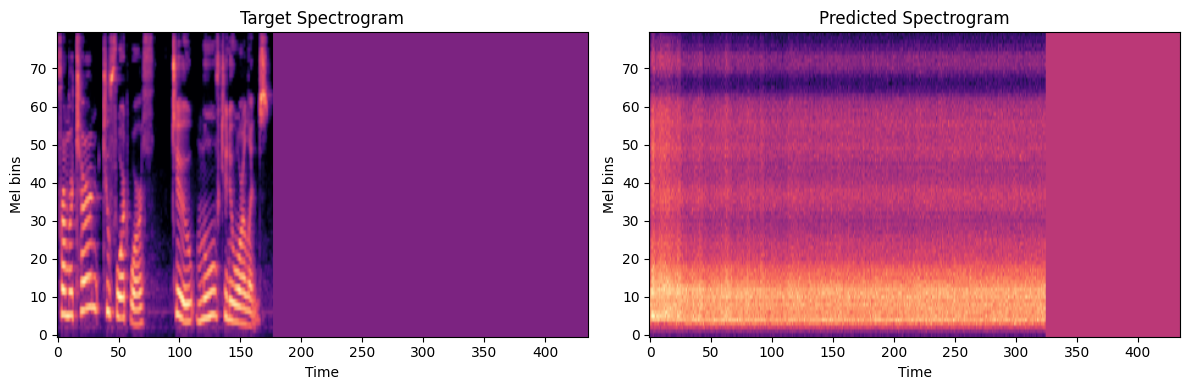

In [ ]:
import matplotlib.pyplot as plt

single_spec = spectrograms[0].detach().cpu().numpy()
single_np = inp_train[0].unsqueeze(0)
single_spec = spectrograms[0].detach().cpu().numpy()
pred,_,g,f =  model(single_np,None,'inf')
pred = pred.detach().cpu().numpy().squeeze(0)
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(single_spec, origin='lower', aspect='auto', cmap='magma')
plt.title("Target Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel bins")

plt.subplot(1,2,2)
plt.imshow(pred, origin='lower', aspect='auto', cmap='magma')
plt.title("Predicted Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel bins")

plt.tight_layout()
plt.show()

In [ ]:
pad_size = inp.shape[1]
def pad_inp(x):
  x = encode(x)
  x = torch.tensor(x,dtype=torch.long)
  x = x.unsqueeze(0)
  return F.pad(x,(0,pad_size-x.shape[1]),value=vocab+1).to(device)

In [ ]:
import soundfile as sf
def mel_to_wav(mel_db, sr=22050, n_fft=1024, hop_length=512, n_iter=100):
    print(mel_db.shape)
    mel_db = mel_db * sp_std
    mel_db = mel_db+sp_mean

    mel_db = mel_db.detach().cpu().numpy()
    mel_power = librosa.db_to_power(mel_db)
    mel_mag = np.sqrt(mel_power)
    stft_mag = librosa.feature.inverse.mel_to_stft(mel_mag, sr=sr, n_fft=n_fft)
    audio = librosa.griffinlim(stft_mag, n_iter=n_iter, hop_length=hop_length, win_length=n_fft)
    return audio
te = pad_inp("In being compartevly modern we are exposing ourselves to risks that are not safe for us")
sp,_,l,i = model(te,None,'inf')
audio = mel_to_wav(sp)
sf.write("output.wav", audio[0], 22050)


torch.Size([1, 80, 435])
